In [52]:
import torch  # 导入 PyTorch：一个处理多维数组（张量）的库
import torch.nn.functional as F  # PyTorch 的函数库（后面用交叉熵损失等）
import matplotlib.pyplot as plt # 导入画图库，用来画训练曲线
%matplotlib inline  # 让图直接显示在 notebook 里

In [53]:
# 读取所有人名
words = open('names.txt', 'r').read().splitlines()  # 打开文件读出全部文字，按行切分成列表
words[:8]  # 显示前 8 个名字

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [54]:
len(words)  # 统计一共有多少个人名

32033

In [55]:
# 建立【字符表】以及“字符 <-> 数字”的双向映射（计算机只认数字，所以要给字符编号）
chars = sorted(list(set(''.join(words))))  # 拼成一大串、去重、排序，得到所有不同字符
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi = “字符→数字”字典，编号从 1 开始
stoi['.'] = 0  # '.' 编号为 0（表示名字结束）
itos = {i:s for s,i in stoi.items()}  # itos = “数字→字符”反向字典
print(itos)  # 打印映射表

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [56]:
# 构建数据集（内联版本，先演示思路）

block_size = 3 # 上下文长度：用前面 3 个字符来预测下一个字符（像“看前几个字猜下一个字”）
X, Y = [], []  # X 存输入（前 3 字符窗口），Y 存正确答案（下一个字符）
for w in words:  # 遍历每个人名

  #print(w)  # （被注释）可打印当前名字
  context = [0] * block_size  # 初始“历史窗口”用 3 个 0（0 代表 '.'）填充
  for ch in w + '.':  # 遍历名字每个字符，最后加 '.' 表示结束
    ix = stoi[ch]  # 当前字符编号
    X.append(context)  # 当前窗口记为一条输入
    Y.append(ix)  # 当前字符记为正确答案
    #print(''.join(itos[i] for i in context), '--->', itos[ix])  # （被注释）调试打印
    context = context[1:] + [ix] # 窗口右滑一格：丢最旧、加最新（像滑动窗口）

X = torch.tensor(X)  # 转成张量
Y = torch.tensor(Y)  # 转成张量

In [57]:
X.shape, X.dtype, Y.shape, Y.dtype  # 查看数据形状和类型（shape=形状，dtype=数据类型）

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [58]:
# 构建数据集（函数版，并划分训练/验证/测试集）
block_size = 3 # 上下文长度

def build_dataset(words):  # 把构建逻辑封装成函数，方便对不同数据子集重复使用
  X, Y = [], []
  for w in words:

    #print(w)  # （被注释）
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])  # （被注释）
      context = context[1:] + [ix] # 窗口右滑

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)  # 打印形状
  return X, Y  # 返回输入和输出

import random
random.seed(42)  # 固定随机种子，保证可复现
random.shuffle(words)  # 打乱名字顺序（避免同类名字扎堆）
n1 = int(0.8*len(words))  # 前 80% 分界点
n2 = int(0.9*len(words))  # 前 90% 分界点

Xtr, Ytr = build_dataset(words[:n1])  # 训练集（80%，用来学习）
Xdev, Ydev = build_dataset(words[n1:n2])  # 验证集（10%，用来挑超参数）
Xte, Yte = build_dataset(words[n2:])  # 测试集（10%，最终评估）

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [59]:
C = torch.randn((27, 2))  # 嵌入表 C：27 个字符，每个用 2 个数字描述（先用 2 维，方便画图可视化）

In [60]:
emb = C[X]  # 查表：把 X 里每个字符编号换成对应的嵌入向量（2 个数字）
emb.shape  # 查看形状，应该是 (样本数, block_size, 2)

torch.Size([228146, 3, 2])

In [61]:
W1 = torch.randn((6, 100))  # 第一层权重：输入 6（3字符×2维）→ 输出 100 个神经元
b1 = torch.randn(100)  # 第一层偏置：100 个数

In [62]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # 把嵌入拼成 6 维 → 乘权重加偏置 → 再过 tanh 激活函数（把值压到 -1~1）

In [63]:
h  # 显示隐藏层输出（100 个神经元的激活值）

tensor([[ 0.9061,  0.8446,  0.1493,  ...,  0.8951, -0.9101, -0.7435],
        [ 0.9917,  0.8720,  0.8568,  ...,  0.3230,  0.4730, -0.8684],
        [ 0.9592,  0.9230, -0.6029,  ..., -0.9818,  0.9864, -0.2957],
        ...,
        [ 0.1890,  0.9784, -0.5315,  ...,  0.9984,  0.0948, -0.9060],
        [ 0.3747,  0.9930, -0.8445,  ...,  0.9989, -0.1136, -0.9778],
        [ 0.1192,  0.9844, -0.2904,  ...,  0.9742, -0.4278, -0.2872]])

In [64]:
h.shape  # 查看形状 (样本数, 100)

torch.Size([228146, 100])

In [65]:
W2 = torch.randn((100, 27))  # 第二层权重：100 → 27（输出 27 个字符的得分）
b2 = torch.randn(27)  # 第二层偏置

In [66]:
logits = h @ W2 + b2  # 输出层：隐藏层结果乘权重加偏置，得到 27 个字符的“得分”

In [67]:
logits.shape  # 查看形状 (样本数, 27)

torch.Size([228146, 27])

In [68]:
counts = logits.exp()  # 取指数，把得分变成正数（相当于“频次”）

In [69]:
prob = counts / counts.sum(1, keepdims=True)  # 归一化成概率（每行加起来等于 1）

In [70]:
prob.shape  # 查看形状 (样本数, 27)

torch.Size([228146, 27])

In [71]:
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean()  # 损失 = 平均负对数似然（取正确字符的概率，取负对数再平均，越小越好）
loss  # 显示损失

tensor(18.0240)

In [72]:
# ------------ 现在开始正式训练（把上面零散的代码整合起来）---------------

In [73]:
Xtr.shape, Ytr.shape # 查看训练集形状

(torch.Size([182625, 3]), torch.Size([182625]))

In [74]:
g = torch.Generator().manual_seed(2147483647) # 固定随机种子，保证可复现
C = torch.randn((27, 10), generator=g)  # 嵌入表：27 字符 × 10 维（每个字符用 10 个数字描述）
W1 = torch.randn((30, 200), generator=g)  # 第一层权重：30（3×10）→ 200 个神经元
b1 = torch.randn(200, generator=g)  # 第一层偏置
W2 = torch.randn((200, 27), generator=g)  # 第二层权重：200 → 27
b2 = torch.randn(27, generator=g)  # 第二层偏置
parameters = [C, W1, b1, W2, b2]  # 把所有参数放进一个列表统一管理

In [75]:
sum(p.nelement() for p in parameters) # 统计参数总数（nelement 是一个张量里数字的个数）

11897

In [76]:
for p in parameters:
  p.requires_grad = True  # 让每个参数都计算梯度（即可被训练）

In [77]:
lre = torch.linspace(-3, 0, 1000)  # 生成 1000 个从 -3 到 0 的数（这是“学习率的对数”，用于搜索最佳学习率）
lrs = 10**lre  # 10 的幂，还原成真正的学习率值（0.001 ~ 1）

In [78]:
lri = []  # 记录学习率（画图用）
lossi = []  # 记录损失
stepi = []  # 记录步数

In [80]:
for i in range(100):  # 训练 100 步（一轮一轮地学）

  # 1. 构造小批量（mini-batch）
  ix = torch.randint(0, Xtr.shape[0], (32,))  # 随机挑 32 个样本的行号

  # 2. 前向传播：数据从输入算到输出，得到预测
  emb = C[Xtr[ix]] # (32, 3, 10)  查表得到嵌入
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)  第一层 + tanh 激活
  logits = h @ W2 + b2 # (32, 27)  第二层得到得分
  loss = F.cross_entropy(logits, Ytr[ix])  # 交叉熵损失（衡量预测和正确答案的差距）
  #print(loss.item())  # （被注释）

  # 3. 反向传播：计算每个参数的梯度（即损失对参数的“敏感度”）
  for p in parameters:
    p.grad = None  # 清零梯度
  loss.backward()  # 自动计算梯度

  # 4. 更新参数：沿梯度反方向走一小步
  #lr = lrs[i]  # （被注释）如果用学习率搜索就用这行
  lr = 0.1 if i < 100000 else 0.01  # 学习率设为 0.1
  for p in parameters:
    p.data += -lr * p.grad  # 梯度下降更新

  # 5. 记录状态
  #lri.append(lre[i])  # （被注释）
  stepi.append(i)  # 记录步数
  lossi.append(loss.log10().item())  # 记录损失（取对数，方便画图）

#print(loss.item())  # （被注释）

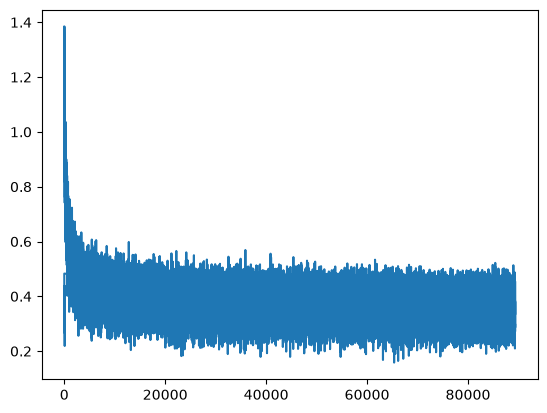

In [81]:
plt.plot(stepi, lossi)  # 画出损失随步数变化的曲线（应呈下降趋势，说明在变好）

In [82]:
emb = C[Xtr] # 训练集前向传播
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)  # 计算整个训练集的损失
loss

tensor(2.2706, grad_fn=<NllLossBackward0>)

In [83]:
emb = C[Xdev] # 验证集前向传播
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)  # 计算验证集损失（用来判断是否过拟合）
loss

tensor(2.3063, grad_fn=<NllLossBackward0>)

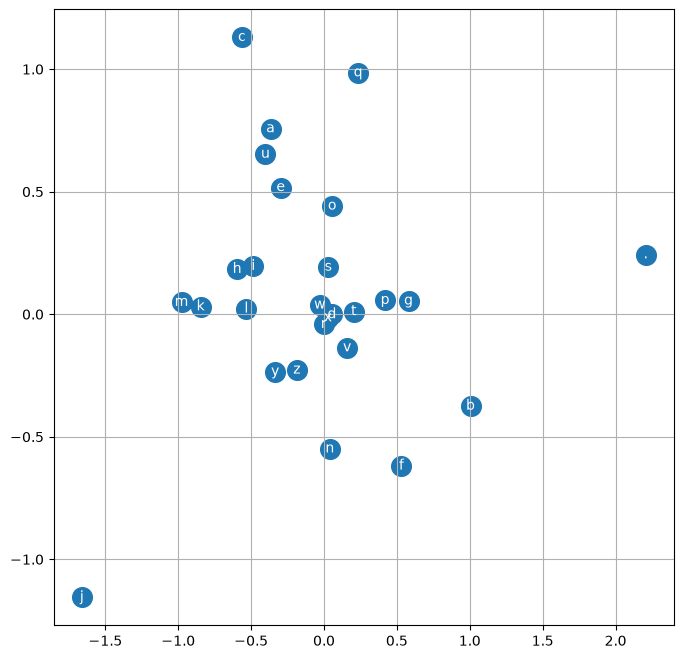

In [84]:
# 可视化嵌入表 C 的第 0 维和第 1 维（把每个字符的 10 维向量取前两维画成散点图）
plt.figure(figsize=(8,8))  # 画布大小
plt.scatter(C[:,0].data, C[:,1].data, s=200)  # 画散点（每个字符一个点）
for i in range(C.shape[0]):  # 遍历每个字符
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')  # 在点上标字符
plt.grid('minor')  # 加网格

In [85]:
# 训练集 / 验证集 / 测试集
# 80% / 10% / 10%

In [86]:
context = [0] * block_size  # 初始上下文窗口（全 0）
C[torch.tensor([context])].shape  # 查表后的形状（1, 3, 10）

torch.Size([1, 3, 10])

In [87]:
# 从模型采样生成新名字
g = torch.Generator().manual_seed(2147483647 + 10)  # 固定随机种子（换个种子得到不同结果）

for _ in range(20):  # 生成 20 个名字

    out = []  # 存生成字符
    context = [0] * block_size # 初始上下文全 0（从空白开始）
    while True:  # 循环直到生成结束符
      emb = C[torch.tensor([context])] # (1,block_size,d) 查表
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)  # 第一层 + tanh
      logits = h @ W2 + b2  # 第二层得分
      probs = F.softmax(logits, dim=1)  # softmax 把得分转成概率
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()  # 按概率抽下一个字符
      context = context[1:] + [ix]  # 窗口右滑
      out.append(ix)  # 记录字符
      if ix == 0:  # 抽到结束符就停
        break

    print(''.join(itos[i] for i in out))  # 解码打印名字

carlah.
aubril.
khkirlee.
tatyannah.
skeem.
hutefandryst.
daquiffremara.
chriia.
dalean.
dhan.
por.
deshan.
sulin.
alian.
quisoer.
giefrysia.
kaellissan.
edde.
iia.
gilee.
